In [8]:
from data_cleanup import functions
regions = functions.regions



import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster



In [9]:
#angepasst auf finale datei
seq_regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
cf_regions = ['CF_H1', 'CF_H2', 'CF_L1', 'CF_L2', 'CF_L3']
df = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset=seq_regions)
    .dropna(subset=cf_regions)
    .drop_duplicates(subset=seq_regions) 
)
antigen_labels = df["antigen_name"].tolist()
antigen_counts = df["antigen_name"].value_counts() # Tabelle aus antigen_names und ihren Häufigkeiten in der Spalte antigen_name
df = df[df["antigen_name"].isin(antigen_counts[antigen_counts >= 5].index)] # Behält nur Zeilen, deren antigen_name mindestens 5-mal vorkommt


In [15]:
#erstellen eines Dictionaries, in dem die Feature-Space DataFrames gespeichert werden, dass nur embeddings verwendet werden aus ab_ag_scalop.tsv in der gefilterten version
feature_spaces = {}

df_rows = df[["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species", "SEQ_H1", "SEQ_H2", "SEQ_L1", "SEQ_L2", "SEQ_L3"]].values.tolist()

for seq_region in seq_regions:
    
    fs_rows = []
    for df_row in df_rows:
        pdb = df_row[0]
        hchain = df_row[1]
        lchain = df_row[2]
        model = df_row[3]
        antigen_name = df_row[4]
        antigen_species = df_row[5]
        match seq_region:
            case "SEQ_H1":
                region = df_row[6]
            case "SEQ_H2":
                region = df_row[7]
            case "SEQ_L1":
                region = df_row[8]
            case "SEQ_L2":
                region = df_row[9]
            case "SEQ_L3":
                region = df_row[10]
        

        if seq_region[4] == "H": #z.B. "H" in "SEQ_H1" oder "L" in "SEQ_L2"
            chain_id = hchain
        else:
            chain_id = lchain

        # Embedding-Koordinaten der PDB-Einträge
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{chain_id}_{seq_region[4]}_{seq_region}_chothia.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb, hchain, lchain, model, antigen_name, antigen_species, region] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)

    # Umwandeln des Feature-Space von einer List in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species", seq_region] + [f"embedding_dimension {e}" for e in range(embedding_as_vec.shape[0])])
    feature_spaces[seq_region] = feature_space


→ SEQ_H1: 712 Sequenzen zum Clustern
   MaxDist=13.359, Cut@50%=6.679


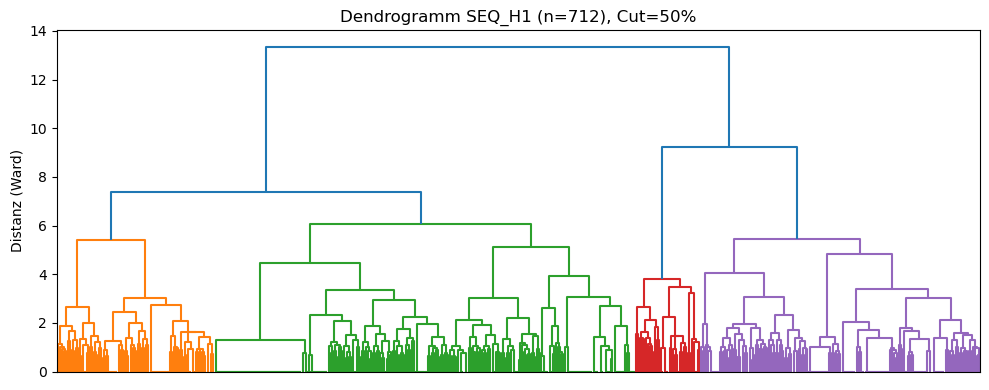


→ SEQ_H2: 712 Sequenzen zum Clustern
   MaxDist=10.447, Cut@50%=5.224


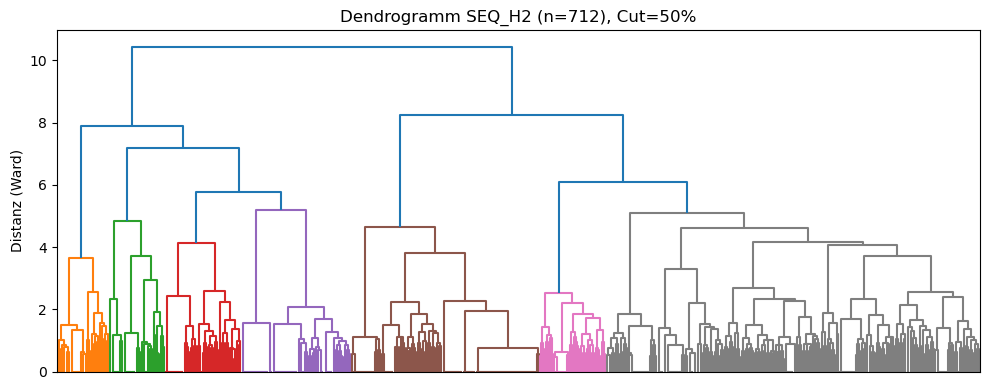


→ SEQ_L1: 712 Sequenzen zum Clustern
   MaxDist=20.233, Cut@50%=10.116


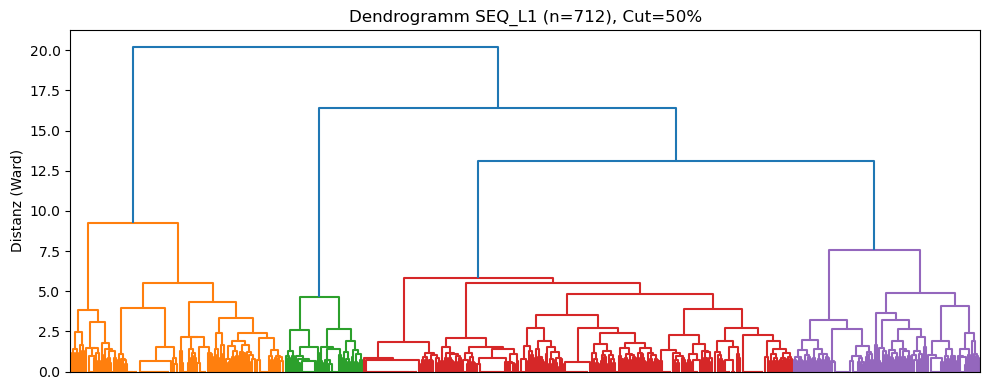


→ SEQ_L2: 712 Sequenzen zum Clustern
   MaxDist=12.782, Cut@50%=6.391


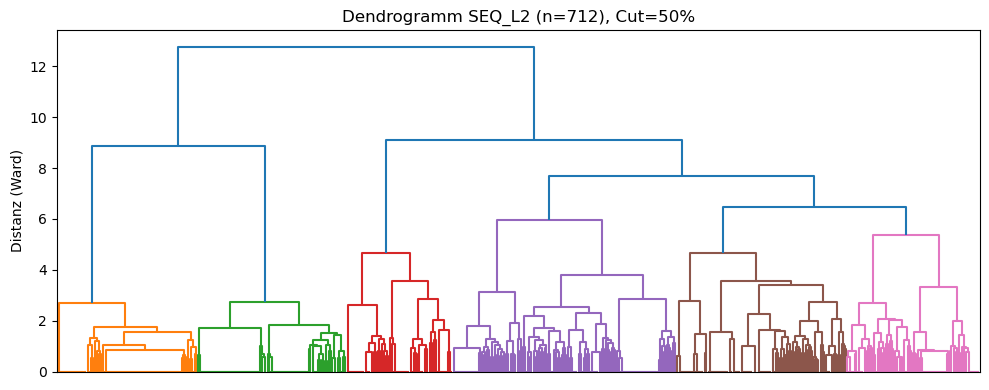


→ SEQ_L3: 712 Sequenzen zum Clustern
   MaxDist=22.485, Cut@50%=11.242


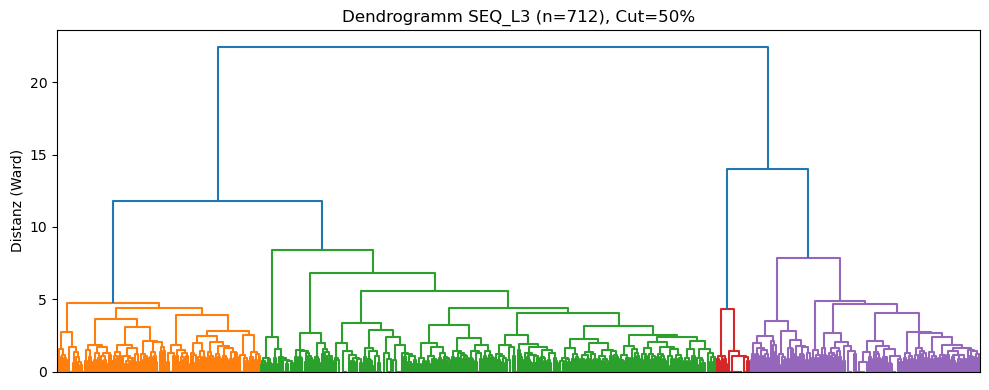

In [ ]:


# --------- Hierarchical Clustering aus bestehenden Feature-Spaces ohne vorsortierung ---------
# Jeder DataFrame enthält Spalten:
#   ['pdb', 'Hchain', 'Lchain', 'sequence',
#    'embedding_dimension 0', ..., 'embedding_dimension N']

threshold_ratio = 0.5  # 50% der maximalen Merge-Distanz als Cut

# Ausgabe-Ordner für TSVs
outdir = "data/cdr_cluster_ESMC_tsvs"
os.makedirs(outdir, exist_ok=True)

for region in seq_regions:
    fs = feature_spaces.get(region)
    if fs is None or fs.empty:
        continue

    # 1) Embedding-Spalten sammeln
    emb_cols = [c for c in fs.columns if c.startswith('embedding_dimension')]
    if not emb_cols:
        continue

    # 2) Feature‐Matrix und Labels
    X = fs[emb_cols].values
    #unique namen erstellen für die einträge
    labels = (
        fs['pdb'].astype(str)
        + '_' + fs['Hchain'].fillna('')
        + fs['Lchain'].fillna('')
    )
    #anzahl der gefundenen einträge (Zeilen)
    n = X.shape[0]
    print(f"\n→ {region}: {n} Sequenzen zum Clustern")
    if n < 2:
        continue

    # 3) Ward‐Linkage
    Z = linkage(X, method='ward', metric='euclidean')
    max_dist = Z[-1,2]
    cut = threshold_ratio * max_dist
    print(f"   MaxDist={max_dist:.3f}, Cut@{threshold_ratio*100:.0f}%={cut:.3f}")

    # 4) Cluster‐Labels ermitteln
    clusters = fcluster(Z, t=cut, criterion="distance")
    fs['cluster'] = clusters  # neue Spalte im DataFrame

    # 5) TSV schreiben – komplett alle Spalten + cluster
    out_path = os.path.join(outdir, f"clusters_{region}.tsv")
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        # Header: alle Spaltennamen
        writer.writerow(list(fs.columns))
        # Daten
        writer.writerows(fs.values)
    
    # 6) Dendrogramm plotten
    plt.figure(figsize=(10,4))
    dendrogram(
        Z,
        labels=labels.tolist(),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=cut
    )
    plt.xticks([])
    plt.xlabel("")
    plt.ylabel("Distanz (Ward)")
    plt.title(f"Dendrogramm {region} (n={n}), Cut={int(threshold_ratio*100)}%")
    plt.tight_layout()
    plt.show()


→ SEQ_H1, Länge=7: 642 Sequenzen
   MaxDist=12.819, Cut@50 % = 6.410


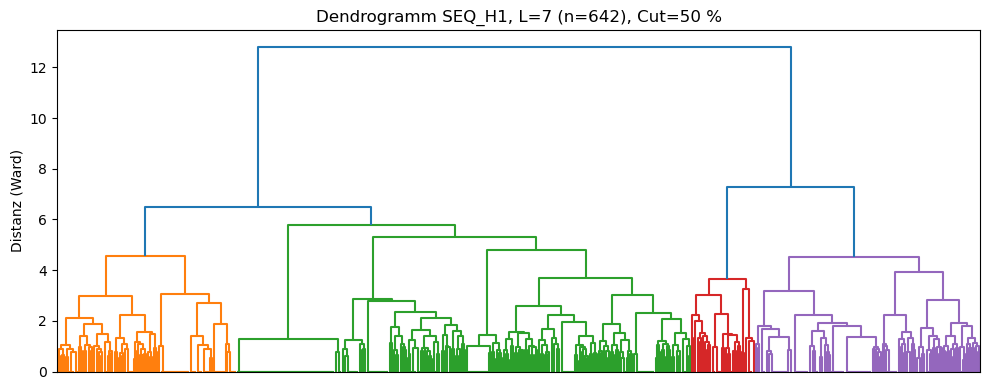


→ SEQ_H1, Länge=8: 11 Sequenzen
   MaxDist=3.903, Cut@50 % = 1.951


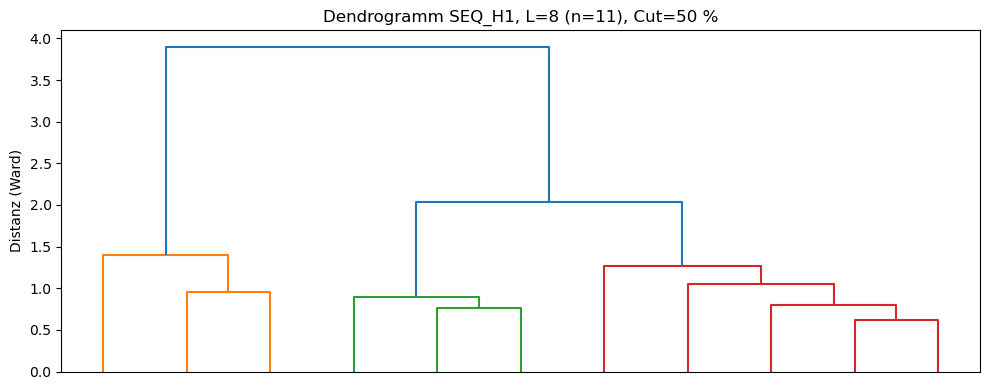


→ SEQ_H1, Länge=9: 59 Sequenzen
   MaxDist=5.489, Cut@50 % = 2.745


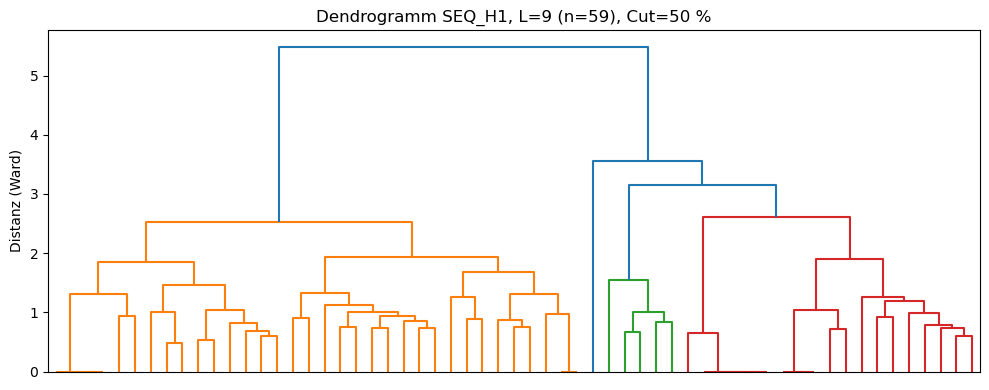


→ SEQ_H2, Länge=5: 210 Sequenzen
   MaxDist=5.696, Cut@50 % = 2.848


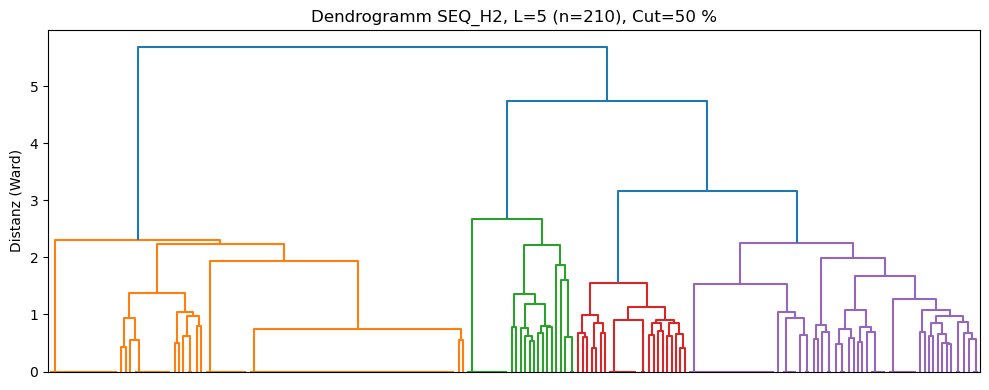


→ SEQ_H2, Länge=6: 488 Sequenzen
   MaxDist=10.288, Cut@50 % = 5.144


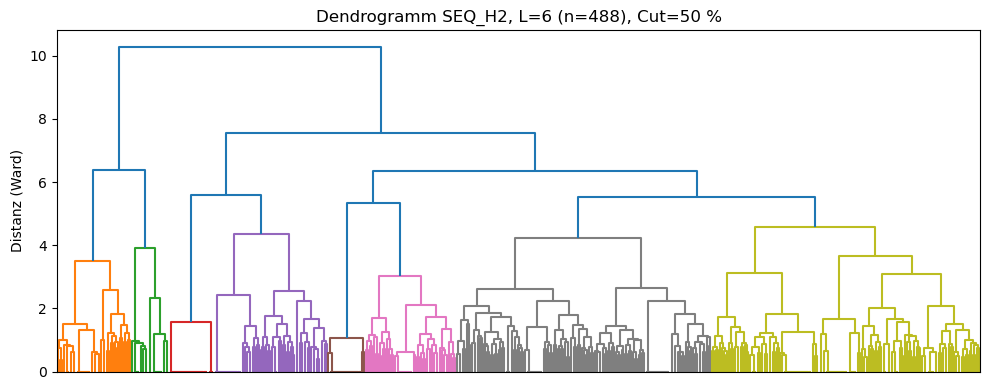


→ SEQ_H2, Länge=8: 14 Sequenzen
   MaxDist=1.890, Cut@50 % = 0.945


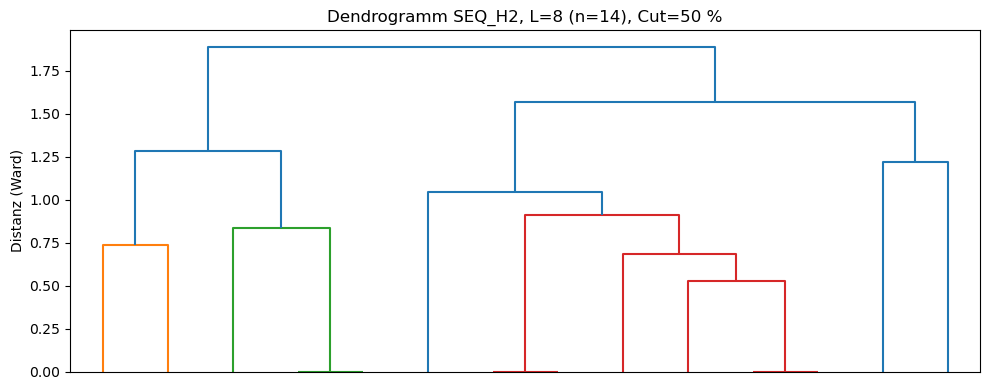


→ SEQ_L1, Länge=10: 2 Sequenzen
   MaxDist=1.491, Cut@50 % = 0.746


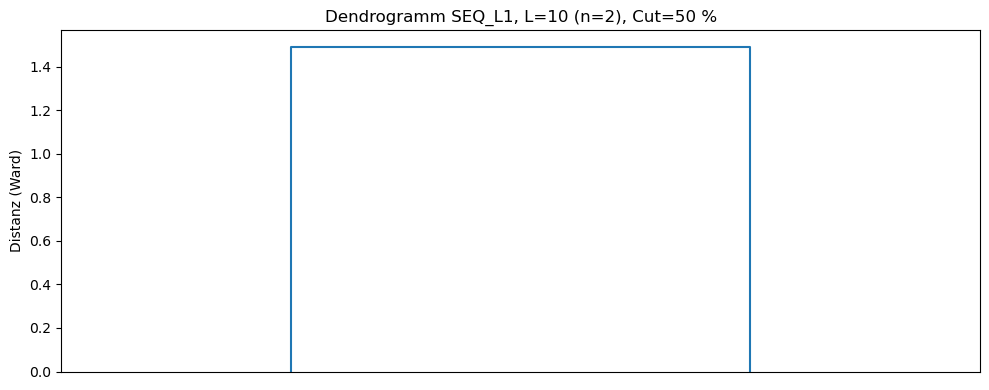


→ SEQ_L1, Länge=11: 387 Sequenzen
   MaxDist=11.942, Cut@50 % = 5.971


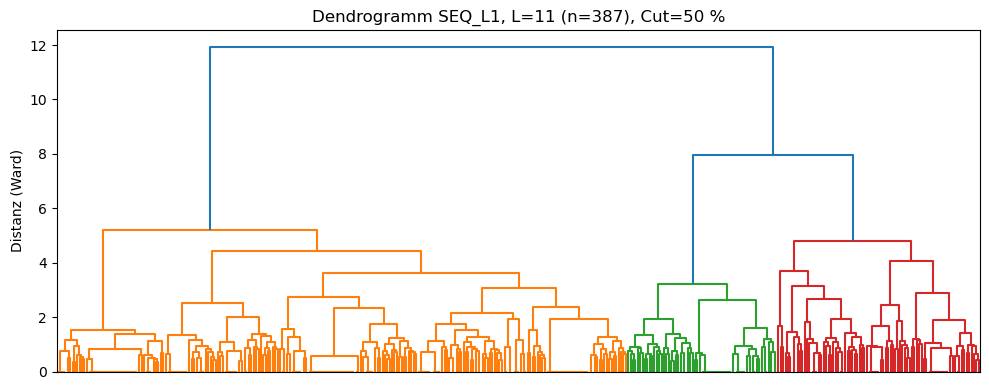


→ SEQ_L1, Länge=12: 98 Sequenzen
   MaxDist=3.830, Cut@50 % = 1.915


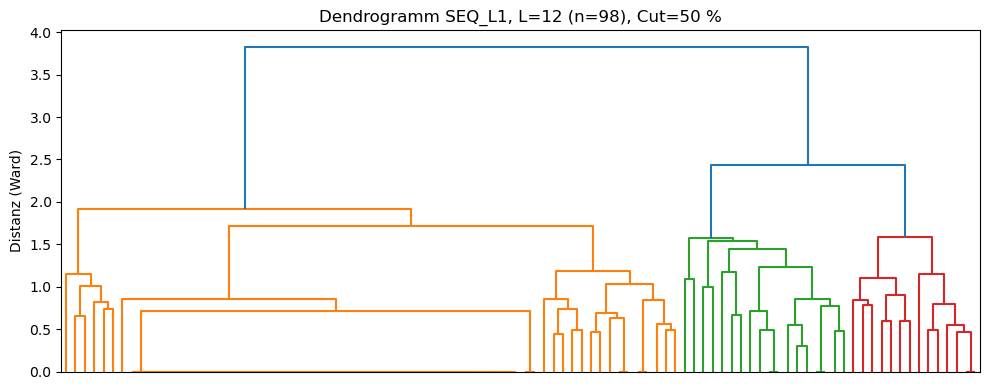


→ SEQ_L1, Länge=13: 59 Sequenzen
   MaxDist=6.262, Cut@50 % = 3.131


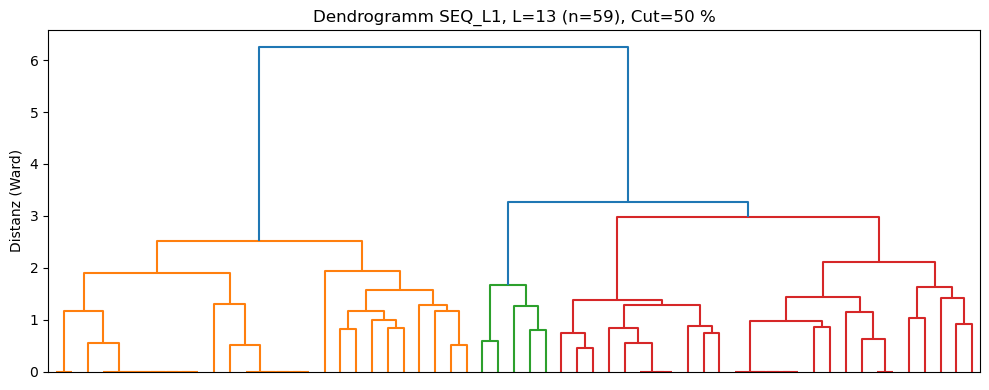


→ SEQ_L1, Länge=14: 101 Sequenzen
   MaxDist=4.842, Cut@50 % = 2.421


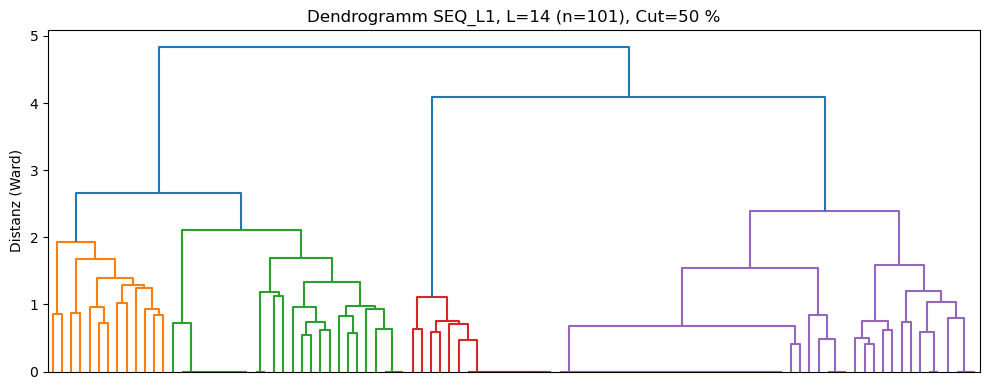


→ SEQ_L1, Länge=15: 5 Sequenzen
   MaxDist=1.433, Cut@50 % = 0.717


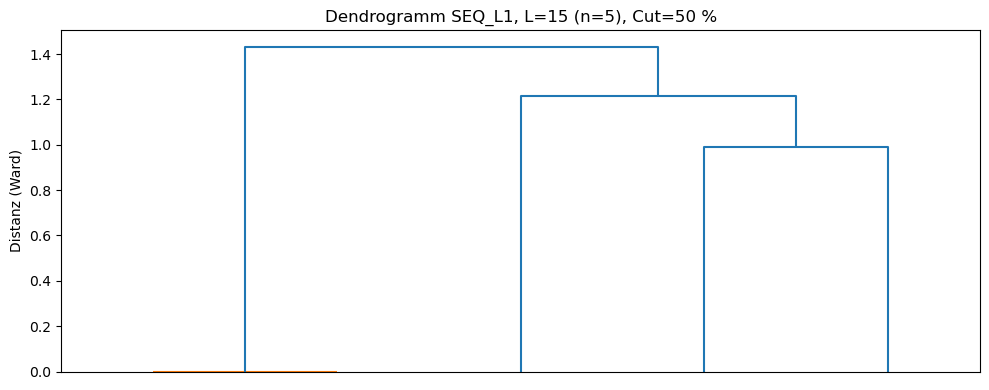


→ SEQ_L1, Länge=16: 35 Sequenzen
   MaxDist=2.614, Cut@50 % = 1.307


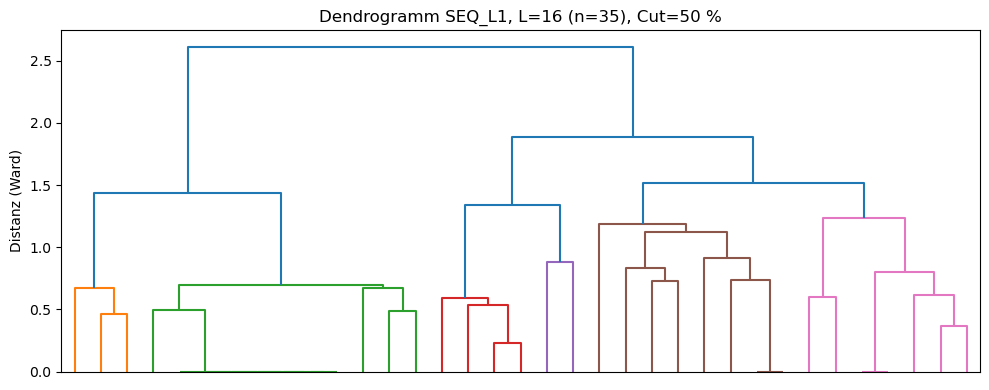


→ SEQ_L1, Länge=17: 25 Sequenzen
   MaxDist=2.314, Cut@50 % = 1.157


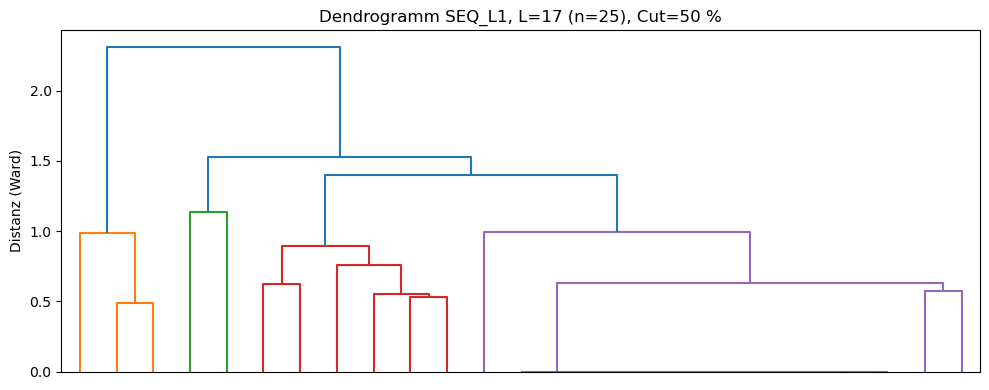


→ SEQ_L2, Länge=7: 712 Sequenzen
   MaxDist=12.782, Cut@50 % = 6.391


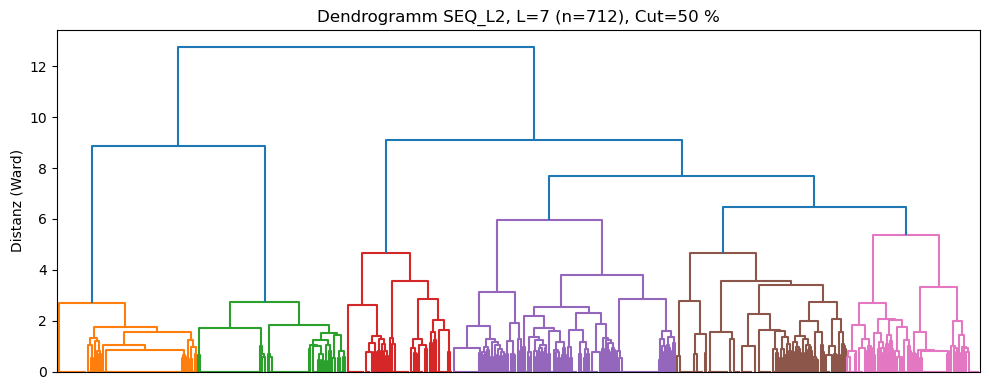


→ SEQ_L3, Länge=5: 9 Sequenzen
   MaxDist=2.405, Cut@50 % = 1.202


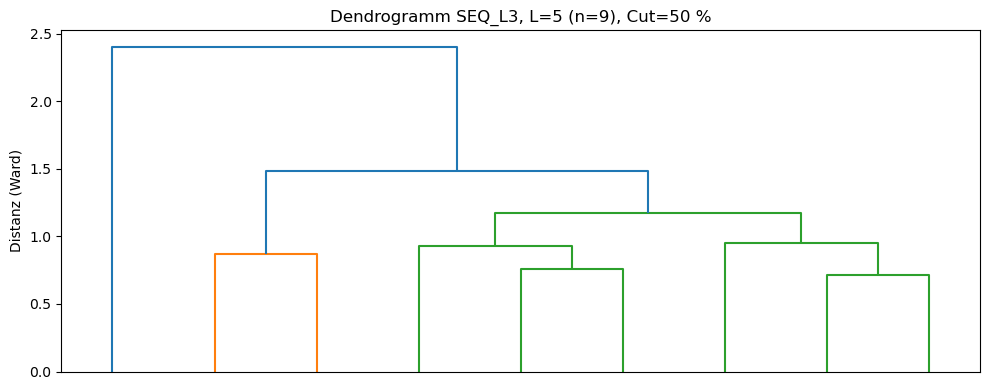


→ SEQ_L3, Länge=8: 47 Sequenzen
   MaxDist=4.389, Cut@50 % = 2.195


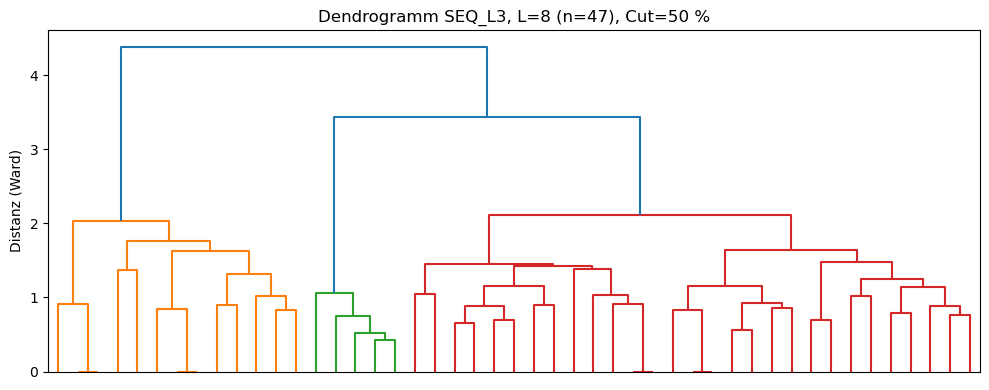


→ SEQ_L3, Länge=9: 390 Sequenzen
   MaxDist=21.161, Cut@50 % = 10.580


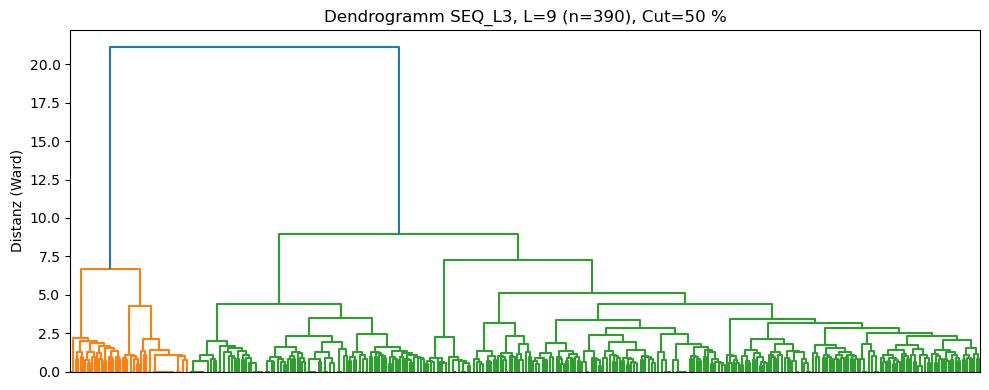


→ SEQ_L3, Länge=10: 161 Sequenzen
   MaxDist=8.704, Cut@50 % = 4.352


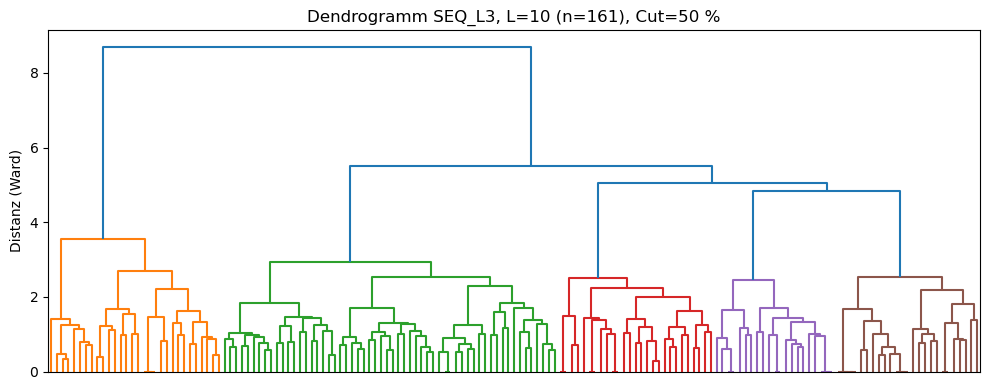


→ SEQ_L3, Länge=11: 105 Sequenzen
   MaxDist=5.478, Cut@50 % = 2.739


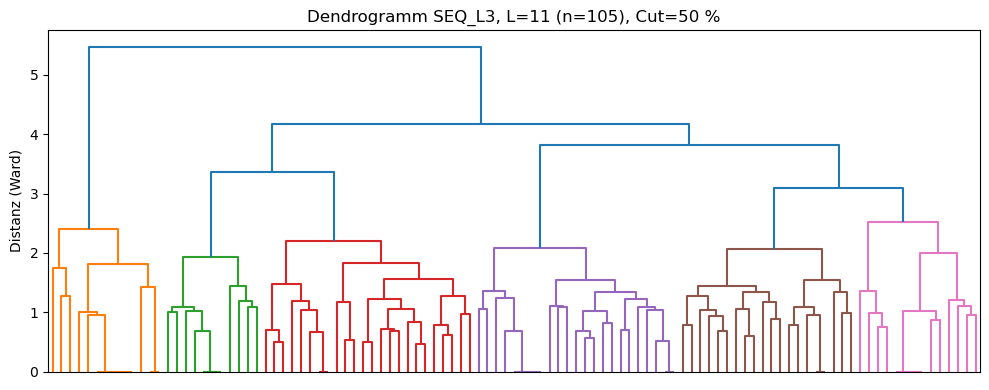

In [ ]:


# --------- Hierarchical Clustering nach Sequenzlängen (L) ---------

# 50 % der maximalen Merge-Distanz als Cut
threshold_ratio = 0.5

# CDR-Regionen (gleich den Keys in feature_spaces)


# Ausgabe-Ordner anlegen
outdir = "data/cdr_cluster_ESMC_by_length_tsvs"
os.makedirs(outdir, exist_ok=True)

for region in seq_regions:
    fs = feature_spaces.get(region)
    if fs is None or fs.empty:
        continue

    # Berechne Sequenz-Längen
    
    fs["length"] = [len(i) for i in fs[region]]
    lengths = sorted(fs["length"].unique())

    for L in lengths:
        # Subset nur dieser Länge
        sub = fs[fs["length"] == L].reset_index(drop=True)
        n = len(sub)
        print(f"\n→ {region}, Länge={L}: {n} Sequenzen")

        if n < 2:
            continue

        # 1) Embedding-Spalten sammeln
        emb_cols = [c for c in sub.columns if c.startswith("emb_") or c.startswith("embedding_dimension")]
        if not emb_cols:
            continue

        # 2) Feature-Matrix und Labels
        X = sub[emb_cols].values
        labels = ( sub["pdb"].astype(str)
                 + "_" + sub["Hchain"].fillna("")
                 + "_" + sub["Lchain"].fillna("") ).tolist()

        # 3) Ward-Linkage
        Z = linkage(X, method="ward", metric="euclidean")
        max_dist = Z[-1,2]
        cut = threshold_ratio * max_dist
        print(f"   MaxDist={max_dist:.3f}, Cut@{int(threshold_ratio*100)} % = {cut:.3f}")

        # 4) Cluster-Labels ermitteln
        sub["cluster"] = fcluster(Z, t=cut, criterion="distance")

        # 5) TSV schreiben (alle Spalten + cluster)
        out_path = os.path.join(outdir, f"clusters_{region}_len{L}.tsv")
        with open(out_path, "w", newline="") as f:
            writer = csv.writer(f, delimiter="\t")
            writer.writerow(list(sub.columns))           # Header
            writer.writerows(sub.values)                 # alle Zeilen
        

        # 6) Dendrogramm plotten
        plt.figure(figsize=(10,4))
        dendrogram(
            Z,
            labels=labels,
            leaf_rotation=90,
            leaf_font_size=6,
            color_threshold=cut
        )
        plt.xticks([]); plt.xlabel("")
        plt.ylabel("Distanz (Ward)")
        plt.title(f"Dendrogramm {region}, L={L} (n={n}), Cut={int(threshold_ratio*100)} %")
        plt.tight_layout()
        plt.show()

3

→ SEQ_H1, Länge=7: 642 Sequenzen


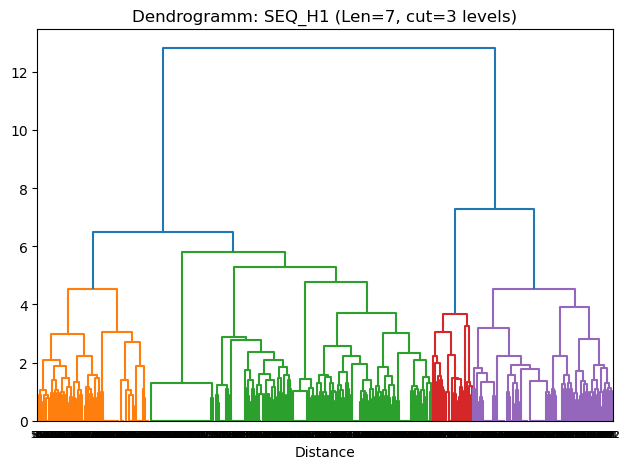

1

→ SEQ_H1, Länge=8: 11 Sequenzen


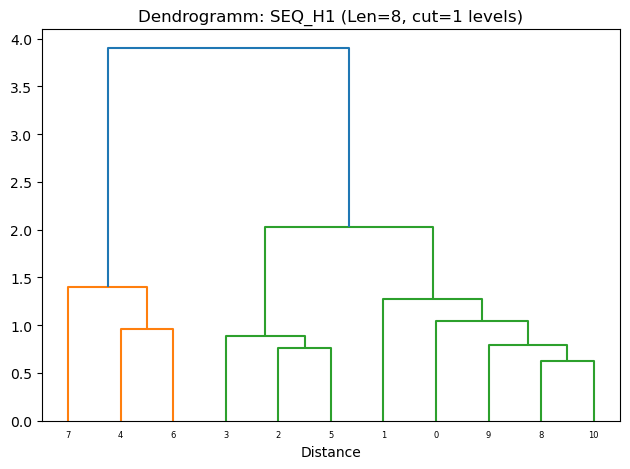

0

→ SEQ_H1, Länge=9: 59 Sequenzen


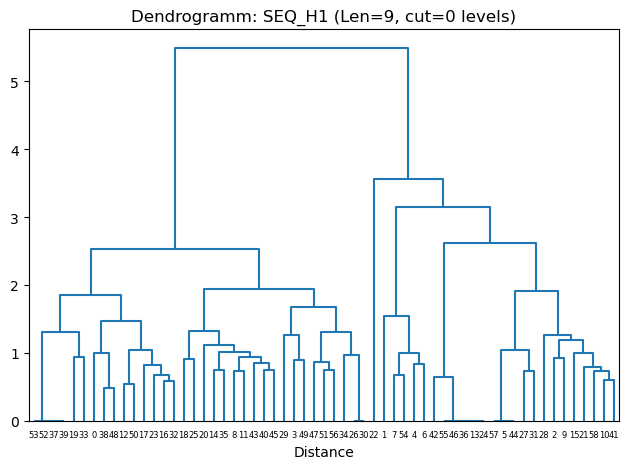

0

→ SEQ_H2, Länge=5: 210 Sequenzen


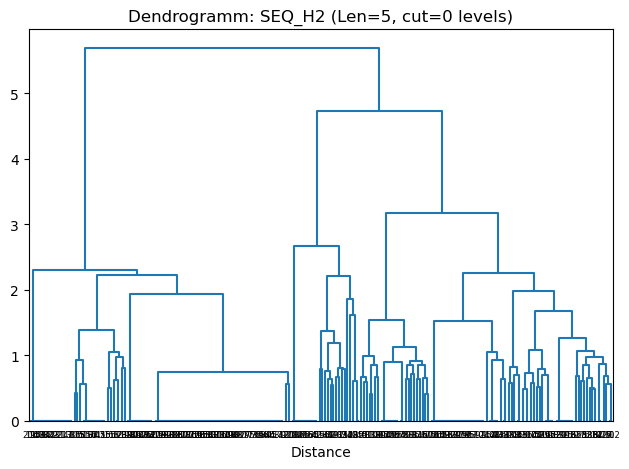

4

→ SEQ_H2, Länge=6: 488 Sequenzen


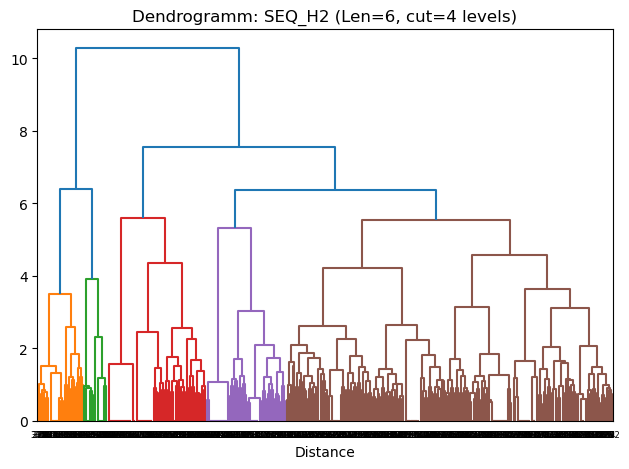

0

→ SEQ_H2, Länge=8: 14 Sequenzen


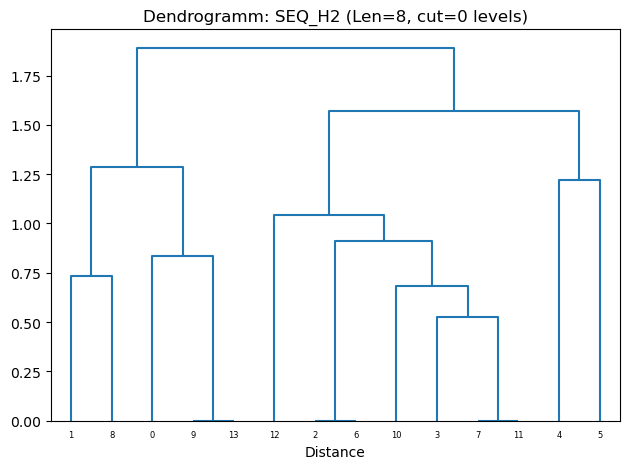

0

→ SEQ_L1, Länge=10: 2 Sequenzen


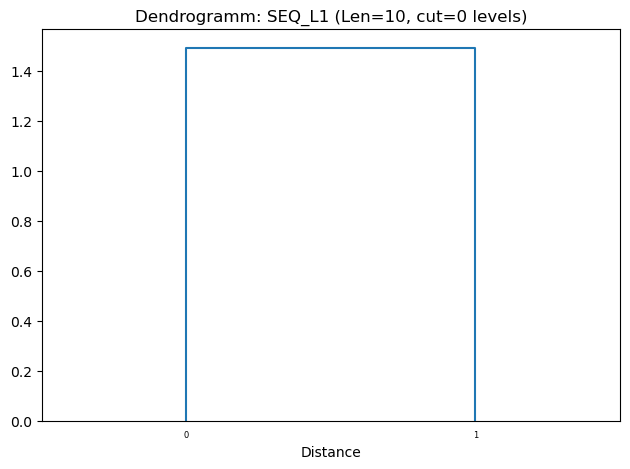

1

→ SEQ_L1, Länge=11: 387 Sequenzen


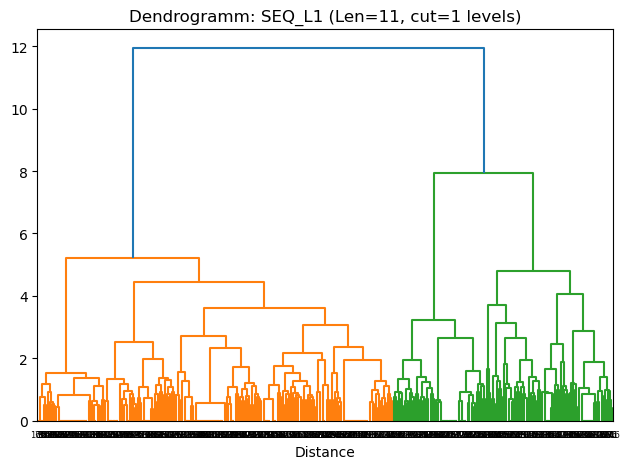

1

→ SEQ_L1, Länge=12: 98 Sequenzen


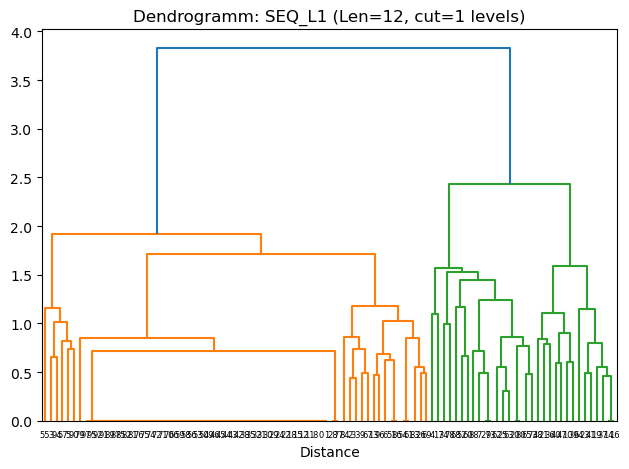

2

→ SEQ_L1, Länge=13: 59 Sequenzen


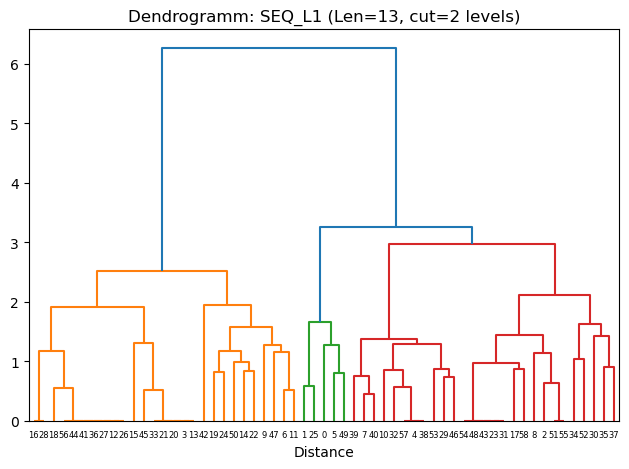

2

→ SEQ_L1, Länge=14: 101 Sequenzen


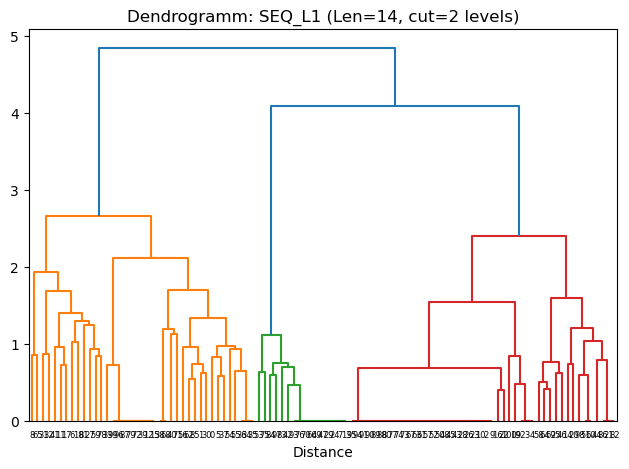

0

→ SEQ_L1, Länge=15: 5 Sequenzen


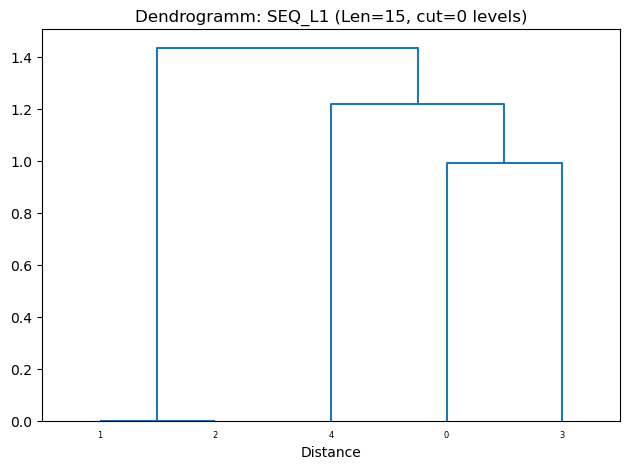

0

→ SEQ_L1, Länge=16: 35 Sequenzen


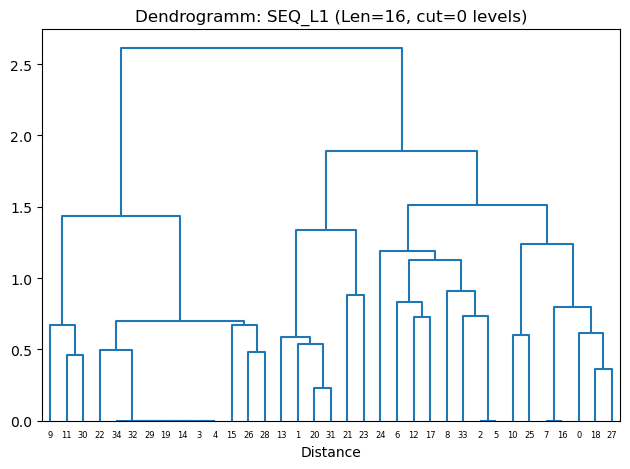

0

→ SEQ_L1, Länge=17: 25 Sequenzen


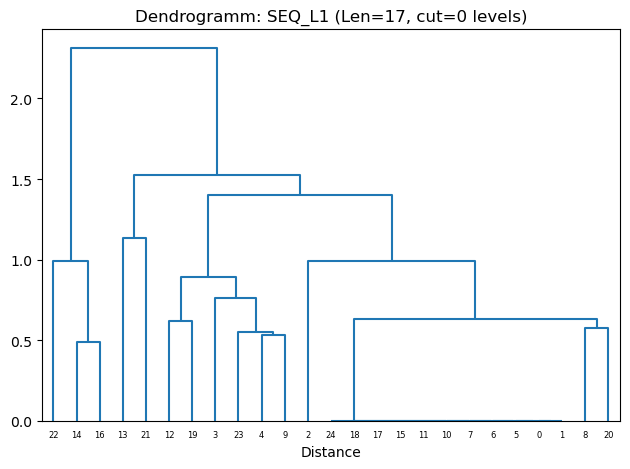

0

→ SEQ_L2, Länge=7: 712 Sequenzen


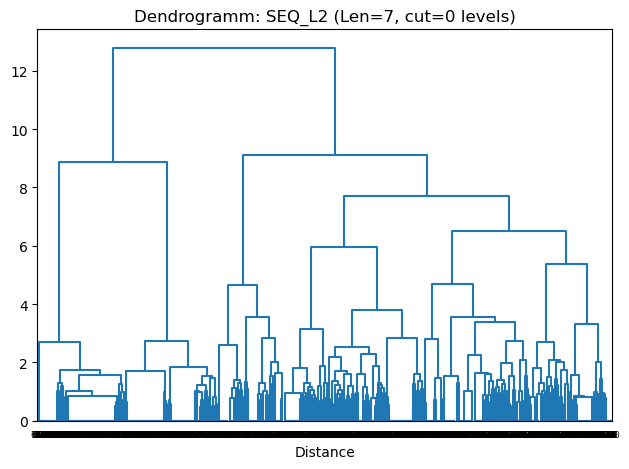

0

→ SEQ_L3, Länge=5: 9 Sequenzen


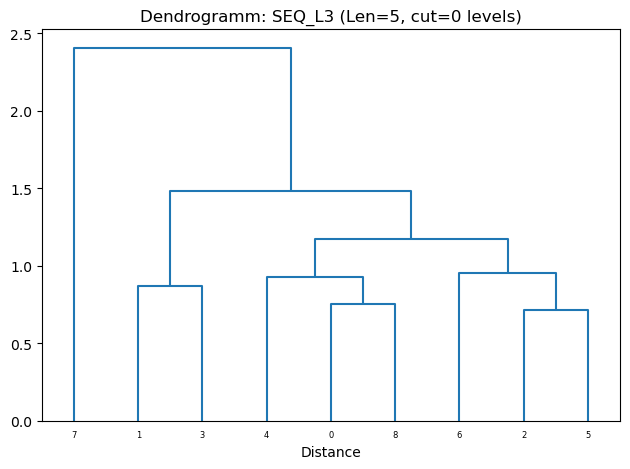

0

→ SEQ_L3, Länge=8: 47 Sequenzen


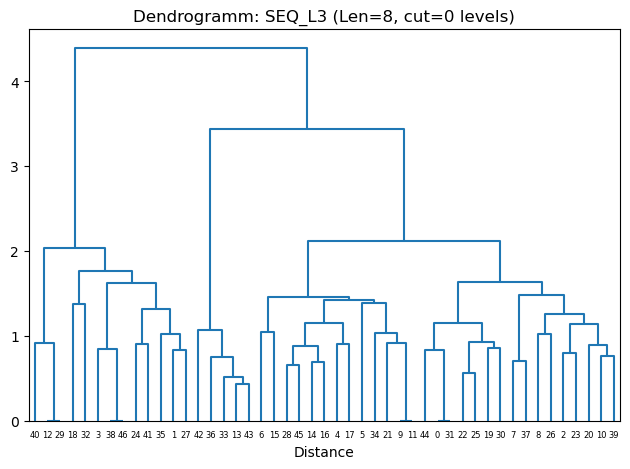

0

→ SEQ_L3, Länge=9: 390 Sequenzen


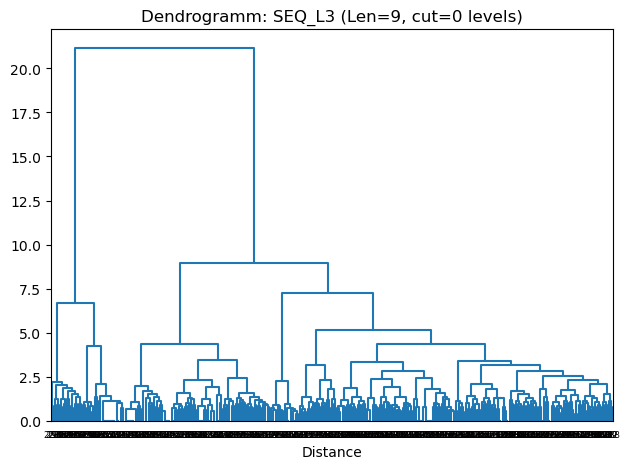

1

→ SEQ_L3, Länge=10: 161 Sequenzen


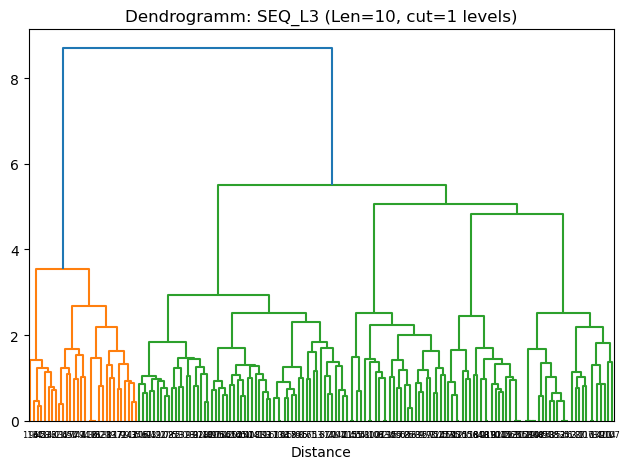

0

→ SEQ_L3, Länge=11: 105 Sequenzen


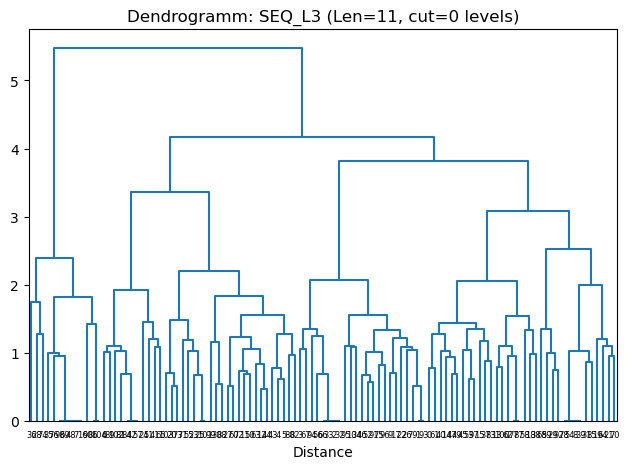

In [ ]:



# CDR-Regionen (gleich den Keys in feature_spaces)


# Ausgabe-Ordner anlegen
outdir = "data/cdr_cluster_ESMC_by_length_pre_defined_tsvs"
os.makedirs(outdir, exist_ok=True)

cluster_counts = {
    ("SEQ_H1", 7): 4, ("SEQ_H1", 8): 2, ("SEQ_H1", 9): 1,
    ("SEQ_H2", 5): 1, ("SEQ_H2", 6): 5, ("SEQ_H2", 8): 1,
    ("SEQ_L1",10): 1, ("SEQ_L1",11): 2, ("SEQ_L1",12): 2,
    ("SEQ_L1",13): 3, ("SEQ_L1",14): 3, ("SEQ_L1",15): 1,
    ("SEQ_L1",16): 1, ("SEQ_L1",17): 1,
    ("SEQ_L2", 7): 1,
    ("SEQ_L3", 5): 1, ("SEQ_L3", 8): 1, ("SEQ_L3", 9): 1,
    ("SEQ_L3",10): 2, ("SEQ_L3",11): 1,
}
for region in seq_regions:
    fs = feature_spaces.get(region)
    if fs is None or fs.empty:
        continue

    # Berechne Sequenz-Längen
    
    fs["length"] = [len(i) for i in fs[region]]
    lengths = sorted(fs["length"].unique())

    for L in lengths:
# Parameter für Dendrogramm-Cut
        levels_down = cluster_counts.get((region, L), 1)-1  # Anzahl der Ebenen für den Cut; etwa 2 = 3 Teilbäume
        print(levels_down)

        sub = fs[fs["length"] == L].reset_index(drop=True)
        n = len(sub)
        print(f"\n→ {region}, Länge={L}: {n} Sequenzen")

        if n < 2:
            continue

        # 1) Embedding-Spalten sammeln
        emb_cols = [c for c in sub.columns if c.startswith("emb_") or c.startswith("embedding_dimension")]
        if not emb_cols:
            continue

        # 2) Feature-Matrix und Labels
        X = sub[emb_cols].values
        # Hierarchisches Clustering
        Z = linkage(X, method="ward", metric="euclidean")
        threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0

        # Dendrogrammdaten ohne Plot für Farbzuordnung
        ddata = dendrogram(
            Z,
            labels=[str(i) for i in range(len(sub[region].tolist()))],
            color_threshold=threshold,
            no_plot=True
        )

        # Blatt-Farben extrahieren
        leaves = ddata['leaves']
        leaf_colors = ddata['leaves_color_list']
        leaf_color_map = dict(zip(leaves, leaf_colors))

        # Eindeutige Farben in Erscheinungsreihenfolge sammeln
        unique_colors = []
        for col in leaf_colors:
            if col not in unique_colors:
                unique_colors.append(col)
        color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}

        # TSV-Einträge sammeln
        entries = []
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            for leaf_idx in leaves_in_cluster:
                pdb_id = sub.iloc[leaf_idx]['pdb']
                entries.append((pdb_id, region, L, cid))

        # Schreibe TSV für Region und Länge
        
        # 5) TSV schreiben (alle Spalten + cluster)
        out_path = os.path.join(outdir, f"cdr_clusters_ESMC{region}_len{L}_pre_decided.tsv")
        with open(out_path, "w", newline="") as f:
            writer = csv.writer(f, delimiter="\t")
            writer.writerow(list(sub.columns))           # Header
            writer.writerows(sub.values)                 # alle Zeilen

        # Plot Dendrogramm        plt.figure(figsize=(8, 6))
        dendrogram(
            Z,
            labels=[str(i) for i in range(len(sub[region].tolist()))],
            color_threshold=threshold,
            leaf_rotation=0,
            leaf_font_size=6
        )
        plt.title(f"Dendrogramm: {region} (Len={L}, cut={levels_down} levels)")
        plt.xlabel("Distance")
        plt.tight_layout()
        plt.show()

       

In [71]:
print(fs.columns)

Index(['pdb', 'Hchain', 'Lchain', 'model', 'antigen_name', 'antigen_species',
       'SEQ_L3', 'embedding_dimension 0', 'embedding_dimension 1',
       'embedding_dimension 2',
       ...
       'embedding_dimension 1144', 'embedding_dimension 1145',
       'embedding_dimension 1146', 'embedding_dimension 1147',
       'embedding_dimension 1148', 'embedding_dimension 1149',
       'embedding_dimension 1150', 'embedding_dimension 1151', 'cluster',
       'length'],
      dtype='object', length=1161)


KeyError: 'CDR_H1'

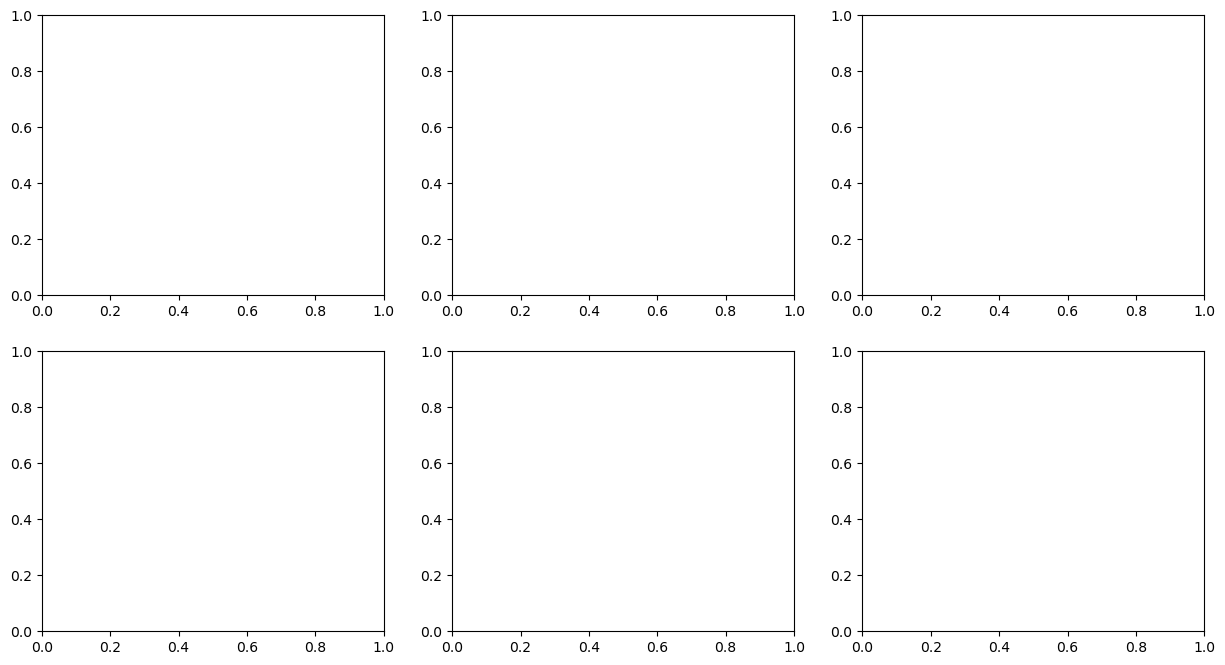

In [16]:
import data_cleanup.functions
data_cleanup.functions.show_PCA(feature_spaces, 3)